# Notebook


## 1. Setup

In [49]:
import sys
import json
import shutil
from pathlib import Path

ROOT = Path.cwd()
RUNS_DIR = ROOT / "runs"

for _p in (ROOT, ROOT / "project", ROOT / "project" / "export",
           ROOT / "yolo", ROOT / "yolo" / "eval"):
    p = str(_p)
    if p not in sys.path:
        sys.path.insert(0, p)

# Reutilise les helpers du pipeline
from runs import find_runs

print(f"ROOT     = {ROOT}")
print(f"RUNS_DIR = {RUNS_DIR}  (exists={RUNS_DIR.exists()})")

ROOT     = c:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF
RUNS_DIR = c:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs  (exists=True)


## 2. Lister les runs disponibles

In [39]:
runs = find_runs(all_runs=True)
for r in runs:
    print(f"  - {r.name}")
print(f"\n{len(runs)} run(s) trouve(s).")

  - KPDX_10L
  - KPDX_10L_002

2 run(s) trouve(s).


## 3. Création du dataset (Regroupement des dossiers d'images)

In [40]:
IMG_EXTS = (".jpg", ".jpeg", ".png")

def build_dataset(out_dir: Path = RUNS_DIR / "dataset") -> dict:
    """Pour chaque run, copie les images de degraded/ (prio) ou footage/ vers out_dir."""
    if out_dir.exists():
        shutil.rmtree(out_dir)
    out_dir.mkdir(parents=True)

    summary = {}
    for run in find_runs(all_runs=True):
        src = run / "degraded"
        kind = "degraded"
        if not src.exists() or not any(src.iterdir()):
            src = run / "footage"
            kind = "footage"
        if not src.exists():
            summary[run.name] = (kind, 0, "absent")
            continue

        n = 0
        for img in src.iterdir():
            if img.suffix.lower() in IMG_EXTS:
                shutil.copy2(img, out_dir / img.name)
                n += 1
        summary[run.name] = (kind, n, "ok")

    total = sum(n for _, n, _ in summary.values())
    print(f"Dataset : {out_dir}")
    for name, (kind, n, status) in summary.items():
        print(f"  {name:<25} <- {kind:<8} ({n:>4} imgs) [{status}]")
    print(f"Total : {total} images")
    return summary

build_dataset();

[SKIP] dataset : pas de .yaml
Dataset : c:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs\dataset
  KPDX_10L                  <- degraded ( 231 imgs) [ok]
  KPDX_10L_002              <- degraded ( 231 imgs) [ok]
Total : 462 images


4. Generer `yolo_box/` (images avec bbox YOLO dessinees)

Lit `predictions.csv` du run, dessine les bbox sur les images sources
(`degraded/` en priorite, sinon `footage/`) et ecrit dans `runs/<run>/yolo_box/`.

Usage :
- `build_yolo_box("LFPO_24")` : une seule run
- `build_yolo_box()`           : toutes les runs

In [52]:
from ultralytics import YOLO

def build_yolo_box(run_name: str | None = None,
                   line_width: int = 2, conf: float = 0.25, imgsz: int = 512):
    """Trace les bbox YOLO (trait fin) dans run_dir/yolo_box/. None = tous les runs.

    Meme appel que yolo/predict.py (model.predict + save=True), seul `line_width`
    est ajoute (non expose par predict()).
    """
    targets = find_runs(run_name=run_name, all_runs=run_name is None)
    model = YOLO(str(ROOT / "yolo" / "yolov8n.pt"))
    for run in targets:
        src = run / "degraded"
        if not src.exists() or not any(src.iterdir()):
            src = run / "footage"
        out = run / "yolo_box"
        if out.exists():
            shutil.rmtree(out)
        model.predict(source=str(src), conf=conf, imgsz=imgsz, save=True,
                      line_width=line_width, project=str(run), name="yolo_box",
                      exist_ok=True, verbose=False)
        print(f"  {run.name} -> yolo_box/")

build_yolo_box()

Results saved to C:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs\KPDX_10L\yolo_box
  KPDX_10L -> yolo_box/
Results saved to C:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs\KPDX_10L_002\yolo_box
  KPDX_10L_002 -> yolo_box/


## 5. Sanity check : 3 images avec bbox YOLO 

Affiche première / milieu / dernière image d'un run avec les bbox YOLO dessinées
 (`degraded/` prio sinon `footage/`).

Usage : `show_sanity("LFPO_24")` ou `show_sanity()` (= premier run trouvé).

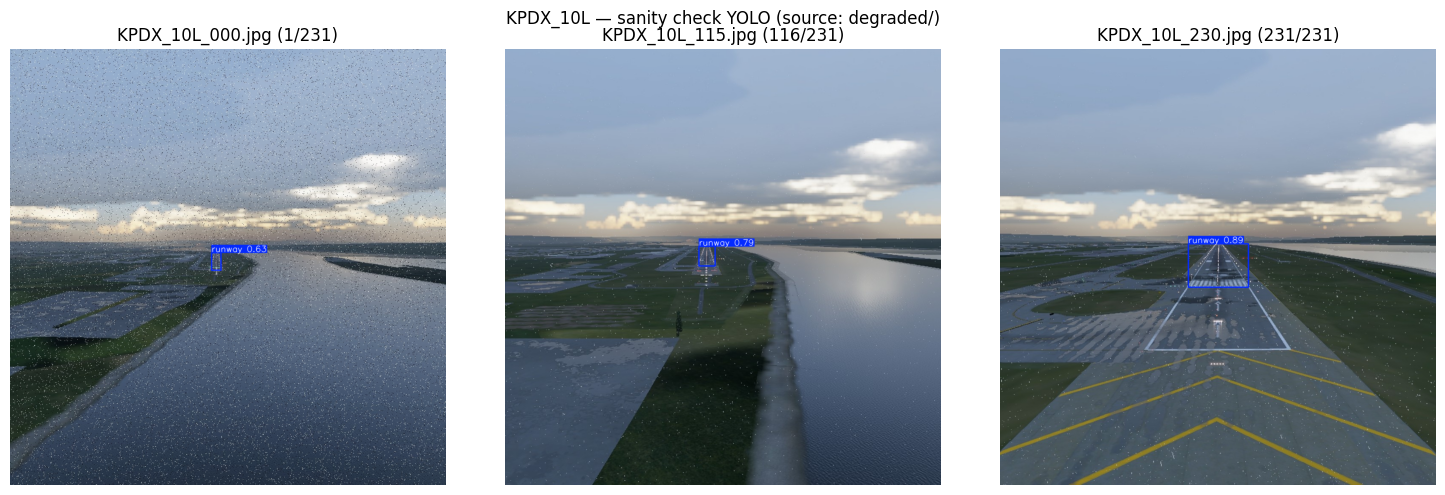

In [53]:
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

def show_sanity(run_name: str | None = None,
                line_width: int = 2, conf: float = 0.25, imgsz: int = 512):
    """Affiche premiere / milieu / derniere image avec bbox YOLO via result.plot()."""
    targets = find_runs(run_name=run_name, all_runs=run_name is None)
    if not targets:
        print("[!] aucun run trouve")
        return
    run = targets[0]

    src = run / "degraded"
    if not src.exists() or not any(src.iterdir()):
        src = run / "footage"
    images = sorted(p for p in src.iterdir() if p.suffix.lower() in IMG_EXTS)
    if not images:
        print(f"[!] pas d'images dans {src}")
        return

    n = len(images)
    picks = [(images[0], 0), (images[n // 2], n // 2), (images[-1], n - 1)]

    model = YOLO(str(ROOT / "yolo" / "yolov8n.pt"))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (img_path, idx) in zip(axes, picks):
        result = model.predict(source=str(img_path), conf=conf, imgsz=imgsz,
                               verbose=False)[0]
        annotated = result.plot(line_width=line_width)  # numpy BGR avec bbox
        ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{img_path.name} ({idx + 1}/{n})")
        ax.axis("off")
    fig.suptitle(f"{run.name} — sanity check YOLO (source: {src.name}/)")
    plt.tight_layout()
    plt.show()

show_sanity()

## 6. Generer `lard_box/` (images avec bbox GT LARD dessinées)

Usage : `build_lard_box("LFPO_24")` ou `build_lard_box()` (toutes les runs).

In [54]:
from lard_bridge import annotate_gt

def build_lard_box(run_name: str | None = None):
    """Genere lard_box/ dans une run (si run_name) ou toutes (si None).

    Reutilise annotate_gt() du pipeline puis renomme annotated_lard/ -> lard_box/
    et retire le prefixe gt_ des fichiers.
    """
    targets = find_runs(run_name=run_name, all_runs=run_name is None)
    for run in targets:
        out = run / "lard_box"
        old = run / "annotated_lard"
        if out.exists():
            shutil.rmtree(out)
        if old.exists():
            shutil.rmtree(old)

        annotate_gt(run)

        if not old.exists():
            print(f"  [skip] {run.name} : annotate_gt n'a rien produit")
            continue
        old.rename(out)
        for f in out.iterdir():
            if f.name.startswith("gt_"):
                f.rename(out / f.name[3:])
        print(f"  {run.name} -> lard_box/")

build_lard_box()

  [GT-VIS] 231 images annotees dans annotated_lard/
  KPDX_10L -> lard_box/
  [GT-VIS] 231 images annotees dans annotated_lard/
  KPDX_10L_002 -> lard_box/


## 7. Sanity check : 3 images avec bbox GT LARD 

Affiche première / milieu / dernière image d'un run avec les 4 coins GT LARD
(`degraded/` prio sinon `footage/`).

Usage : `show_sanity_lard("LFPO_24")` ou `show_sanity_lard()` (= premier run).

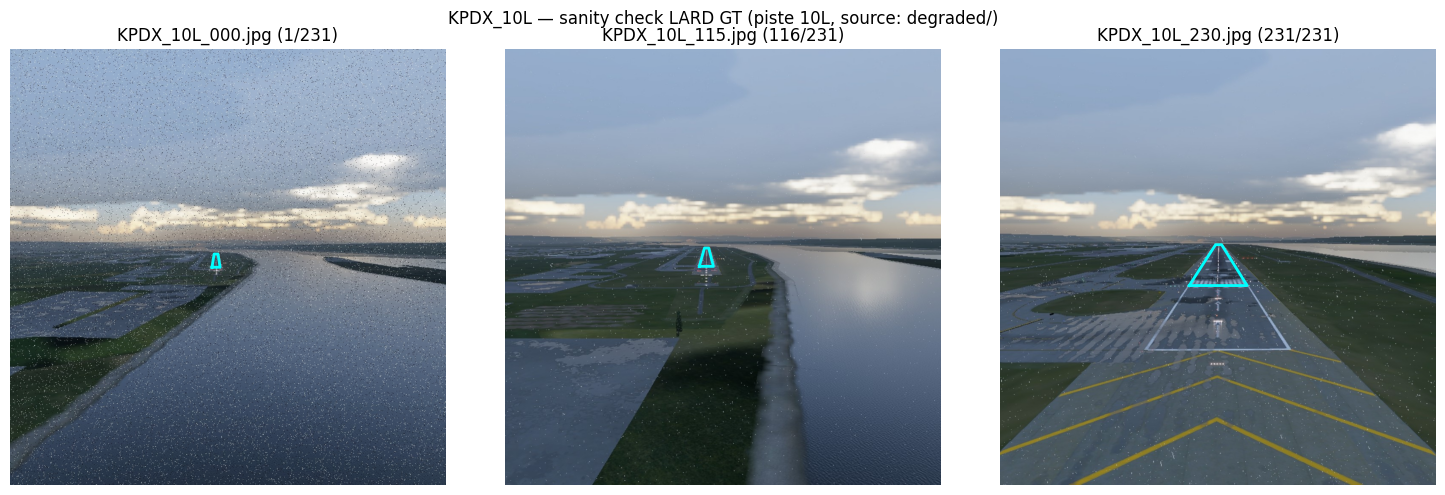

In [55]:
from runway import reciprocal_runway, runway_from_run_name

def _norm(rwy: str) -> str:
    return str(rwy).lstrip("0") or "0"

def _load_gt(run_dir: Path, target_runway: str | None = None) -> dict:
    """*_labels.csv -> {image_name: [[(x,y) x4 corners], ...]}.

    Si target_runway fourni, filtre sur cette piste + son reciprocal (meme bande).
    """
    csvs = list(run_dir.glob("*_labels.csv"))
    if not csvs:
        return {}

    keep = None
    if target_runway:
        keep = {_norm(target_runway), _norm(reciprocal_runway(target_runway))}

    out: dict = {}
    with open(csvs[0], encoding="utf-8") as f:
        reader = csv.DictReader(f, delimiter=";")
        for row in reader:
            if keep is not None and _norm(row.get("runway", "")) not in keep:
                continue
            fname = Path(row["image"]).name
            corners = [
                (float(row["x_TR"]), float(row["y_TR"])),
                (float(row["x_TL"]), float(row["y_TL"])),
                (float(row["x_BL"]), float(row["y_BL"])),
                (float(row["x_BR"]), float(row["y_BR"])),
            ]
            out.setdefault(fname, []).append(corners)
    return out

def show_sanity_lard(run_name: str | None = None, line_width: int = 2):
    """Affiche premiere / milieu / derniere image avec bbox GT LARD (piste cible uniquement)."""
    targets = find_runs(run_name=run_name, all_runs=run_name is None)
    if not targets:
        print("[!] aucun run trouve")
        return
    run = targets[0]

    src = run / "degraded"
    if not src.exists() or not any(src.iterdir()):
        src = run / "footage"
    images = sorted(p for p in src.iterdir() if p.suffix.lower() in IMG_EXTS)
    if not images:
        print(f"[!] pas d'images dans {src}")
        return

    target_rwy = runway_from_run_name(run.name)
    gt = _load_gt(run, target_runway=target_rwy)
    if not gt:
        print(f"[!] pas de GT pour piste {target_rwy} dans {run}")
        return

    n = len(images)
    picks = [(images[0], 0), (images[n // 2], n // 2), (images[-1], n - 1)]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (img_path, idx) in zip(axes, picks):
        img = Image.open(img_path)
        ax.imshow(img)
        for corners in gt.get(img_path.name, []):
            xs = [c[0] for c in corners] + [corners[0][0]]
            ys = [c[1] for c in corners] + [corners[0][1]]
            ax.plot(xs, ys, color="cyan", linewidth=line_width)
        ax.set_title(f"{img_path.name} ({idx + 1}/{n})")
        ax.axis("off")
    fig.suptitle(f"{run.name} — sanity check LARD GT (piste {target_rwy}, source: {src.name}/)")
    plt.tight_layout()
    plt.show()

show_sanity_lard()

## 8. Generer `xplane_config.json`

Reconstruit `runs/<run>/xplane_config.json` depuis le yaml (résolution pré-crop, FOV) et
`weather_profile.json` (status). `pilot_eye_*` (dépend de l'avion choisi sur XPLANE12)

Usage : `build_xplane_config("LFPO_24")` ou `build_xplane_config()` (toutes).

In [45]:
import yaml

# Defaults Cessna 172 (vus dans les anciens xplane_config.json)
PILOT_EYE_DEFAULT = {"x": -0.25, "y": 0.40, "z": 0.26}

def build_xplane_config(run_name: str | None = None):
    """Ecrit run_dir/xplane_config.json depuis yaml + weather_profile.json."""
    targets = find_runs(run_name=run_name, all_runs=run_name is None)
    for run in targets:
        yamls = list(run.glob("*.yaml"))
        if not yamls:
            print(f"  [skip] {run.name} : pas de yaml")
            continue
        meta = yaml.safe_load(yamls[0].read_text())
        img = meta.get("image", {})

        weather_status = "absent"
        wp = run / "weather_profile.json"
        if wp.exists():
            weather_status = "ok"

        cfg = {
            "width": int(img.get("width", 1024)),
            "height": int(img.get("height", 1024)),
            "fov_h": float(img.get("fov_x", 60.0)),
            "fov_v": float(img.get("fov_y", 60.0)),
            "pilot_eye_x": PILOT_EYE_DEFAULT["x"],
            "pilot_eye_y": PILOT_EYE_DEFAULT["y"],
            "pilot_eye_z": PILOT_EYE_DEFAULT["z"],
            "weather_status": weather_status,
        }
        out = run / "xplane_config.json"
        with open(out, "w") as f:
            json.dump(cfg, f, indent=2)
        print(f"  {run.name} -> xplane_config.json ({cfg['width']}x{cfg['height']}, weather={weather_status})")

build_xplane_config()

[SKIP] dataset : pas de .yaml
  KPDX_10L -> xplane_config.json (1024x1024, weather=ok)
  KPDX_10L_002 -> xplane_config.json (1024x1024, weather=ok)


## 9. Generer `params_trace.xml`

Reconstruit `runs/<run>/params_trace.xml` 

Usage : `build_params_trace("LFPO_24")` ou `build_params_trace()` (toutes).

In [46]:
from xml.etree import ElementTree as ET
from xml.dom import minidom

def _xml_value(parent, tag, value):
    el = ET.SubElement(parent, tag)
    el.text = f"{value}"

def build_params_trace(run_name: str | None = None):
    """Ecrit run_dir/params_trace.xml en agregeant les profils JSON."""
    targets = find_runs(run_name=run_name, all_runs=run_name is None)
    for run in targets:
        poses = json.loads((run / "poses_cam_export.json").read_text()) \
            if (run / "poses_cam_export.json").exists() else {}
        weather = (json.loads((run / "weather_profile.json").read_text()).get("weather", {})
                   if (run / "weather_profile.json").exists() else {})
        faults = (json.loads((run / "fault_profile.json").read_text()).get("faults", [])
                  if (run / "fault_profile.json").exists() else [])

        root = ET.Element("test_case")
        scenario = ET.SubElement(root, "scenario", instance="0/0")

        traj = ET.SubElement(scenario, "trajectory", instance="0/0")
        if "fps" in poses:
            _xml_value(traj, "fps", poses["fps"])
        for k, v in poses.get("trajectory", {}).items():
            _xml_value(traj, k, v)

        wn = ET.SubElement(scenario, "weather", instance="0/0")
        for k, v in weather.items():
            _xml_value(wn, k, v)

        fn = ET.SubElement(scenario, "faults", instance="0/0")
        for f in faults:
            ftype = f.get("fault_type", "unknown")
            sub = ET.SubElement(fn, ftype, instance="0/0")
            for k, v in f.items():
                if k == "fault_type":
                    continue
                _xml_value(sub, k, v)

        xml_str = minidom.parseString(ET.tostring(root)).toprettyxml(indent="  ")
        (run / "params_trace.xml").write_text(xml_str, encoding="utf-8")
        print(f"  {run.name} -> params_trace.xml")

build_params_trace()

[SKIP] dataset : pas de .yaml
  KPDX_10L -> params_trace.xml
  KPDX_10L_002 -> params_trace.xml


## 10. Générer une video MP4 du run/des runs

Concatene les images du run (`degraded/` prio sinon `footage/`) en un MP4 (fps .xml)

Usage :
- `build_video("LFPO_24")` : une seule run
- `build_video()`           : toutes les runs
- `build_video(source="footage")` : force la source (`footage` ou `degraded`)

In [48]:
import cv2

def build_video(run_name: str | None = None, source: str | None = None):
    """Genere runs/<run>/<run>.mp4 (fps depuis poses_cam_export.json).

    source : 'degraded' ou 'footage' (defaut: degraded prio sinon footage).
    """
    targets = find_runs(run_name=run_name, all_runs=run_name is None)
    for run in targets:
        if source:
            src = run / source
        else:
            src = run / "degraded"
            if not src.exists() or not any(src.iterdir()):
                src = run / "footage"
        if not src.exists():
            print(f"  [skip] {run.name} : {src.name}/ absent")
            continue

        images = sorted(p for p in src.iterdir() if p.suffix.lower() in IMG_EXTS)
        if not images:
            print(f"  [skip] {run.name} : pas d'images dans {src.name}/")
            continue

        fps = 10
        poses_file = run / "poses_cam_export.json"
        if poses_file.exists():
            fps = int(json.loads(poses_file.read_text()).get("fps", 10))

        first = cv2.imread(str(images[0]))
        if first is None:
            print(f"  [skip] {run.name} : impossible de lire {images[0].name}")
            continue
        h, w = first.shape[:2]

        out = run / f"{run.name}.mp4"
        writer = cv2.VideoWriter(str(out), cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
        for img_path in images:
            img = cv2.imread(str(img_path))
            if img is not None:
                writer.write(img)
        writer.release()

        print(f"  {run.name} -> {out.name}  ({len(images)} frames @ {fps}fps, {src.name}/)")

build_video()

[SKIP] dataset : pas de .yaml
  KPDX_10L -> KPDX_10L.mp4  (231 frames @ 10fps, degraded/)
  KPDX_10L_002 -> KPDX_10L_002.mp4  (231 frames @ 10fps, degraded/)
